In [76]:
# モジュール
import numpy as np
import random
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
sys.setrecursionlimit(100000000)

In [93]:
# スペック部分
class spec:
    #通常2000回転やって収支を出す
    def __init__(self,a,b,c,d,e):
        self.kaitensuu = a #現在の累計回転数
        self.all = b # 累計回転
        self.balls = c # 現在の出玉
        self.border = d # 1kあたりの回転
        self.limit = e
        self.max = 0 # 最大出玉
        self.min = 0

    def normal(self):
        limit = self.limit #回転数上限
        cost = 250 / self.border # 1回転あたりのコスト
        while True:
            if self.all > limit or self.max-self.min > 96000:
                return self.balls
            x = random.random()
            self.kaitensuu += 1
            self.balls -= cost
            if self.balls < self.min:
                self.min = self.balls
            self.all += 1
            # 天井
            if self.kaitensuu == 1212:
                senkou = random.random()
                if senkou < 1/3:
                    self.kaitensuu = 0
                    self.RLC()
            if x <= 1/639.8:
                self.kaitensuu = 0
                self.balls += 420
                self.rush()
            elif x <= 1/319.9:
                self.kaitensuu = 0
                self.balls += 420
                self.short()

    def RLC(self):
        x = np.random.geometric(1/319.9)
        if x <= 115:
            self.balls += 1400
            self.rush()
        else:
            x = random.random()
            if x < 26/1000:
                self.RLC()
            else:
                self.normal()

    def rush(self):
        x = np.random.geometric(1/97.7)
        if x <= 159:
            self.balls += 1400
            if self.balls > self.max:
                self.max = self.balls
            self.rush()
        else:
            senkou = random.random()
            if senkou < 1/3:
                self.RLC()
            else:
                self.normal()

    def short(self):
        x = np.random.geometric(1/319.9)
        if x <= 104:
            self.balls += 1400
            self.rush()
        else:
            x = random.random()
            if x < 26/1000:
                self.RLC()
            else:
                self.normal()


In [94]:
result = []
for i in tqdm(range(100000)):
    instance = spec(0, 0, 0, 17, 2000) # 初期化
    balls = instance.normal()
    result.append(balls)
result = np.array(result)


100%|██████████| 100000/100000 [00:28<00:00, 3472.99it/s]


平均収支:  905.4787588238239
標準偏差:  20677.305201627823
最大値:  139094.7058823532
最小値:  -29426.47058823442
5%点:  -25786.47058823442
95%点:  40153.5294117643


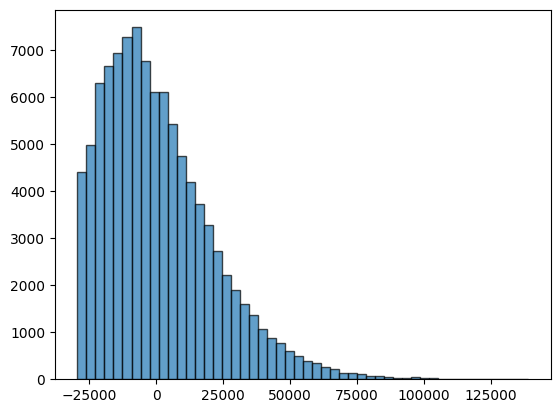

In [95]:
print("平均収支: ", np.mean(result))
print("標準偏差: ", np.std(result))
print("最大値: ", np.max(result))
print("最小値: ", np.min(result))
print("5%点: ", np.percentile(result, 5))
print("95%点: ", np.percentile(result, 95))
plt.hist(np.array(result), bins=50, edgecolor='black', alpha=0.7)
plt.show()